# <a id='toc1_'></a>[Subsampled PSIS-LOO with dockerHDDM](#toc0_)

> A compact workflow for using ArviZ 1.1 `loo_subsample()` with HDDM/kabuki `InferenceData`.

This notebook mirrors the quick-view style: fit a small HDDM model, convert it to ArviZ data, compute full PSIS-LOO, then use subsampled PSIS-LOO for large-data style model checking. The sampling settings are intentionally small so the notebook can be executed as an environment check.

**Table of contents**<a id='toc0_'></a>

- [Subsampled PSIS-LOO with dockerHDDM](#toc1_)
  - [Environment check](#toc1_1_)
  - [Fit a small HDDM model with pointwise log likelihood](#toc1_2_)
  - [Full PSIS-LOO as the reference](#toc1_3_)
  - [Subsampled PSIS-LOO](#toc1_4_)
  - [Updating and reusing a subsample](#toc1_5_)
  - [Save, reload, and run again](#toc1_6_)


## <a id='toc1_1_'></a>[Environment check](#toc0_)

ArviZ 1.1 exposes the stats functions through `arviz` and also through `arviz_stats`. The container should report `az.loo_subsample`, `az.update_subsample`, and a DataTree-style ArviZ object.

In [1]:
import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import arviz_stats
import hddm
import kabuki

print("The current version of kabuki is:", kabuki.__version__)
print("The current version of HDDM is:", hddm.__version__)
print("The current version of arviz is:", az.__version__)
print("az.loo_subsample:", hasattr(az, "loo_subsample"))
print("az.update_subsample:", hasattr(az, "update_subsample"))
print("arviz_stats.loo_subsample:", hasattr(arviz_stats, "loo_subsample"))

The current version of kabuki is: 0.6.5RC4
The current version of HDDM is: 1.0.1RC
The current version of arviz is: 1.1.0
az.loo_subsample: True
az.update_subsample: True
arviz_stats.loo_subsample: True


## <a id='toc1_2_'></a>[Fit a small HDDM model with pointwise log likelihood](#toc0_)

`loo_subsample()` needs posterior samples and pointwise log likelihoods. In dockerHDDM, request them with `return_infdata=True` and `loglike=True`.

Use a disk backend (`db="pickle"` or `save_name=...`) when calculating log likelihoods, because kabuki deep-copies the model during pointwise likelihood generation.

In [2]:
data = hddm.load_csv(hddm.__path__[0] + "/examples/cavanagh_theta_nn.csv")
data = data[data["subj_idx"].isin([0, 1])].groupby("subj_idx").head(20).copy()
data["subj_idx"] = data["subj_idx"].astype(int)

data.head()

,subj_idx,stim,rt,response,theta,dbs,conf
0,0,LL,1.21,1.0,0.656275,1,HC
1,0,WL,1.63,1.0,-0.327889,1,LC
2,0,WW,1.03,1.0,-0.480285,1,HC
3,0,WL,2.77,1.0,1.927427,1,LC
4,0,WW,1.14,0.0,-0.213236,1,HC


In [3]:
save_name = "/tmp/dockerhddm_subsampling_demo"

start = time.time()
model = hddm.HDDM(data, include=["v", "a", "t"], p_outlier=0.05)
idata = model.sample(
    80,
    burn=40,
    chains=1,
    db="pickle",
    dbname="/tmp/dockerhddm_subsampling_demo.db",
    return_infdata=True,
    loglike=True,
    ppc=False,
    save_name=save_name,
    parallel=False,
    find_starting_values=False,
)
print("elapsed seconds:", round(time.time() - start, 3))
print("groups:", idata.groups)
print("posterior sizes:", dict(idata.posterior.sizes))
print("log_likelihood sizes:", dict(idata.log_likelihood["log_lik"].sizes))

No model attribute --> setting up standard HDDM
Set model to ddm


 [-----------------100%-----------------] 80 of 80 complete in 0.2 sec

hddm sampling elpased time:  0.204 s
Start converting to InferenceData...


 [-----------------100%-----------------] 2 of 2 complete in 0.0 sec

The time of calculation of loglikelihood took 0.099 seconds


elapsed seconds: 0.879
groups: ('/', '/observed_data', '/posterior', '/log_likelihood')
posterior sizes: {'chain': 1, 'draw': 40}
log_likelihood sizes: {'chain': 1, 'draw': 40, 'obs_id': 40}


In [4]:
az.summary(idata, var_names=["a", "v", "t"], filter_vars="like")

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,2.2,0.4,1.8,3.2,16,5,NaN,0.16,0.21
a_std,0.6,0.8,0.007,2.2,4,5,NaN,0.43,0.46
a_subj.0,2.5,1,1.9,5.2,4,5,NaN,0.46,0.56
a_subj.1,2.2,0.2,1.9,2.6,9,5,NaN,0.09,0.075
v,0.7,0.9,-0.71,1.9,41,44,NaN,0.15,0.15
v_std,1.5,0.7,0.55,2.8,28,25,NaN,0.14,0.076
v_subj.0,0.6,0.6,-0.093,2.1,26,5,NaN,0.19,0.17
v_subj.1,0.83,0.28,0.43,1.2,30,26,NaN,0.049,0.031
t,0.45,0.12,0.28,0.63,9,22,NaN,0.037,0.024
t_std,0.16,0.2,0.035,0.36,15,14,NaN,0.037,0.062


## <a id='toc1_3_'></a>[Full PSIS-LOO as the reference](#toc0_)

For small datasets, compute full PSIS-LOO first. In ArviZ 1.1, use `elpd` and `p`; older names such as `elpd_loo` and `p_loo` are not the public attributes.

In [5]:
loo_full = az.loo(idata, var_name="log_lik", pointwise=True)
loo_full

Computed from 40 posterior samples and 40 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -105.84    21.04
p_loo       51.78        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.38]   (good)       15   37.5%
   (0.38, 1]   (bad)        18   45.0%
    (1, Inf)   (very bad)    7   17.5%

In [6]:
full_summary = {
    "elpd": loo_full.elpd,
    "se": loo_full.se,
    "p": loo_full.p,
    "n_data_points": loo_full.n_data_points,
    "pareto_k_max": float(loo_full.pareto_k.max()),
}
pd.Series(full_summary)

elpd            -105.839894
se                21.036094
p                 51.776806
n_data_points     40.000000
pareto_k_max       3.456584
dtype: float64

## <a id='toc1_4_'></a>[Subsampled PSIS-LOO](#toc0_)

`observations` can be an integer count sampled without replacement or an explicit array of observation indices. Start with `method="lpd"`; this reuses the stored pointwise log likelihood generated by kabuki.

In [7]:
loo_sub = az.loo_subsample(
    idata,
    observations=10,
    var_name="log_lik",
    pointwise=True,
    method="lpd",
    seed=123,
)
loo_sub

Computed from 40 by 10 subsampled log-likelihood
values from 40 total observations.

         Estimate   SE subsampling SE
elpd_loo    -101.0 14.8            22.3
p_loo         46.9


There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.38]   (good)        5   50.0%
   (0.38, 1]   (bad)         3   30.0%
    (1, Inf)   (very bad)    2   20.0%

In [8]:
sub_summary = {
    "elpd": loo_sub.elpd,
    "se": loo_sub.se,
    "subsampling_se": loo_sub.subsampling_se,
    "p": loo_sub.p,
    "subsample_size": loo_sub.subsample_size,
    "n_data_points": loo_sub.n_data_points,
    "pareto_k_max": float(loo_sub.pareto_k.max()),
}
pd.DataFrame([full_summary, sub_summary], index=["full_loo", "subsampled_loo"])

,elpd,se,p,n_data_points,pareto_k_max,subsampling_se,subsample_size
full_loo,-105.839894,21.036094,51.776806,40,3.456584,NaN,NaN
subsampled_loo,-101.001854,14.835919,46.938766,40,3.148523,22.344844,10.0


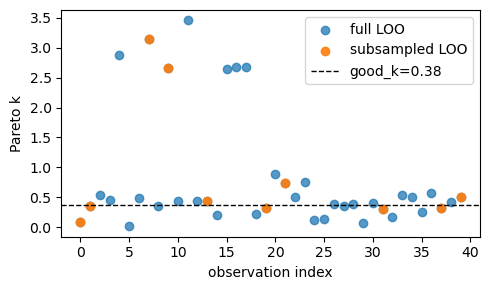

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.arange(loo_full.pareto_k.size), loo_full.pareto_k.values, label="full LOO", alpha=0.75)

sub_k = np.asarray(loo_sub.pareto_k.values).ravel()
sub_obs = np.asarray(loo_sub.loo_subsample_observations).ravel()
if sub_obs.size != sub_k.size:
    sub_obs = np.arange(sub_k.size)
ax.scatter(sub_obs, sub_k, label="subsampled LOO", alpha=0.9)

ax.axhline(loo_full.good_k, color="black", linestyle="--", linewidth=1, label=f"good_k={loo_full.good_k:.2f}")
ax.set_xlabel("observation index")
ax.set_ylabel("Pareto k")
ax.legend()
plt.tight_layout()

## <a id='toc1_5_'></a>[Updating and reusing a subsample](#toc0_)

Use `update_subsample()` to increase the subsample size without starting over conceptually. For model comparison, reuse `loo_subsample_observations` so competing models are compared on the same sampled observations.

In [10]:
loo_sub_updated = az.update_subsample(
    loo_sub,
    idata,
    observations=20,
    var_name="log_lik",
    method="lpd",
    seed=123,
)

pd.DataFrame(
    [
        {"elpd": loo_sub.elpd, "se": loo_sub.se, "subsampling_se": loo_sub.subsampling_se, "subsample_size": loo_sub.subsample_size},
        {"elpd": loo_sub_updated.elpd, "se": loo_sub_updated.se, "subsampling_se": loo_sub_updated.subsampling_se, "subsample_size": loo_sub_updated.subsample_size},
    ],
    index=["initial", "updated"],
)

,elpd,se,subsampling_se,subsample_size
initial,-101.001854,14.835919,22.344844,10
updated,-106.738091,22.227706,11.768506,30


In [11]:
fixed_observations = np.asarray(loo_sub.loo_subsample_observations)
loo_same_observations = az.loo_subsample(
    idata,
    observations=fixed_observations,
    var_name="log_lik",
    pointwise=True,
    method="lpd",
    seed=999,
)

print("fixed observations:", fixed_observations)
print("same observations reused:", np.array_equal(fixed_observations, loo_same_observations.loo_subsample_observations))

fixed observations: [ 0 31  7 13 21 19  9 39 37  1]
same observations reused: False


## <a id='toc1_6_'></a>[Save, reload, and run again](#toc0_)

The ArviZ 1.1 object is a DataTree. It can be saved as NetCDF and reloaded with `az.from_netcdf()`, then used for `loo_subsample()` again.

In [12]:
path = Path(save_name).with_suffix(".nc")
print("saved:", path, "exists:", path.exists(), "bytes:", path.stat().st_size if path.exists() else None)

idata_reloaded = az.from_netcdf(path)
print("reloaded groups:", idata_reloaded.groups)
print("reloaded log_likelihood sizes:", dict(idata_reloaded.log_likelihood["log_lik"].sizes))

saved: /tmp/dockerhddm_subsampling_demo.nc exists: True bytes: 161615
reloaded groups: ('/', '/observed_data', '/posterior', '/log_likelihood')
reloaded log_likelihood sizes: {'chain': 1, 'draw': 40, 'obs_id': 40}


In [13]:
loo_reloaded = az.loo_subsample(
    idata_reloaded,
    observations=10,
    var_name="log_lik",
    pointwise=True,
    method="lpd",
    seed=123,
)

pd.Series({
    "elpd": loo_reloaded.elpd,
    "se": loo_reloaded.se,
    "subsampling_se": loo_reloaded.subsampling_se,
    "subsample_size": loo_reloaded.subsample_size,
    "n_data_points": loo_reloaded.n_data_points,
})

elpd             -101.001854
se                 14.835919
subsampling_se     22.344844
subsample_size     10.000000
n_data_points      40.000000
dtype: float64

## Notes

- `n_loglike` controls how many posterior draws kabuki uses for pointwise log likelihood. It is different from `observations`, which controls observation subsampling in ArviZ.
- Subsampling reduces computation over observations; it does not repair high Pareto-k diagnostics.
- For formal reporting, increase MCMC samples and choose a larger subsample size than used in this quick demonstration.